In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv('data/4-13-2026_rm354_FPB(clean)(vibration).csv')

In [3]:
df.head()

,time,humidity,air_flow,co2,temperature,C8-1(v),C13-1(v),C8-7(v),C13-7(v)
0,2026-04-13 07:54:00,50.799999,1107.528564,424.0,69.619999,0.001061,0.000551,0.002690,0.000534
1,2026-04-13 07:55:00,52.000000,1121.086670,432.0,69.619999,0.001080,0.000554,0.002699,0.000533
2,2026-04-13 07:56:00,52.000000,1108.309937,462.0,69.619999,0.001058,0.000537,0.002699,0.000508
3,2026-04-13 07:57:00,50.799999,1108.309937,441.0,69.619999,0.001046,0.000547,0.002701,0.000507
4,2026-04-13 07:58:00,50.799999,1093.737061,438.0,69.619999,0.000990,0.000559,0.002698,0.000512


In [4]:
est_people = list()

In [5]:
# ── Steady-state CO2 mass-balance occupancy estimate ─────────────────────────
#
# Assumes the room is well-mixed and CO2 concentration is at equilibrium
# (i.e. dC/dt ≈ 0). Under that assumption, CO2 produced by occupants equals
# CO2 removed by ventilation:
#
#       G * N  =  Q * (C_in - C_out)
#
# Solving for the number of people N:
#
#                Q * (C_in - C_out)
#       N  =  ─────────────────────
#                       G
#
# Where:
#   N      = estimated occupants                                    [people]
#   Q      = ventilation/supply airflow rate                        [L/s]
#   C_in   = indoor CO2 concentration (measured)                    [ppm]
#   C_out  = outdoor/background CO2 concentration                   [ppm]
#   G      = per-person CO2 generation rate (ASHRAE typical)        [L/s/person]
#
# The (C_in - C_out) term is divided by 1,000,000 to convert ppm → volume
# fraction so the units of Q*(ΔC) and G match (both L/s).

# ── Room geometry (kept for reference; not used by the steady-state formula) ──
ROOM_AREA_FT2    = 1403                              # AIEB 354 floor area
CEILING_FT       = 13
room_size_m3     = (ROOM_AREA_FT2 * CEILING_FT) * 0.0283168   # ft³ → m³
room_size_liters = room_size_m3 * 1000                        # m³ → L

# ── Model constants ───────────────────────────────────────────────────────────
C_out = 423        # ppm — outdoor/background CO2
G     = 0.005      # L/s/person — per-person CO2 generation rate

# ── Apply the steady-state formula at every timestep ──────────────────────────
for index, row in df.iterrows():
    Q_cfm = df.iloc[index]['air_flow']
    Q     = Q_cfm * 0.47194745                  # CFM → L/s
    C_in  = df.iloc[index]['co2']               # ppm

    delta_C = (C_in - C_out) / 1_000_000        # ppm → volume fraction

    N = (Q * delta_C) / G                       # N = Q·(C_in − C_out) / G
    est_people.append(int(N))

    print(int(N))

0
0
4
1
1
2
1
1
2
0
1
1
1
1
0
0
3
1
0
0
0
2
1
0
0
3
3
1
1
3
1
3
2
1
2
2
3
2
3
2
1
1
1
3
5
4
2
4
2
1
1
1
2
2
2
12
25
21
20
15
12
7
8
12
9
15
19
14
13
6
6
5
5
4
4
3
3
4
5
4
4
4
4
4
4
4
5
5
4
5
5
5
5
5
5
5
5
5
5
5
5
5
5
5
7
6
6
7
6
6
5
6
6
6
6
6
6
8
16
24
22
17
17
15
18
25
21
18
17
16
17
11
10
9
9
9
10
10
10
10
10
9
10
10
10
10
10
10
13
13
18
15
13
12
12
12
13
12
13
12
12
13
13
13
18
15
21
48
19
17
41
43
21
18
28
26
16
15
16
23
50
46
40


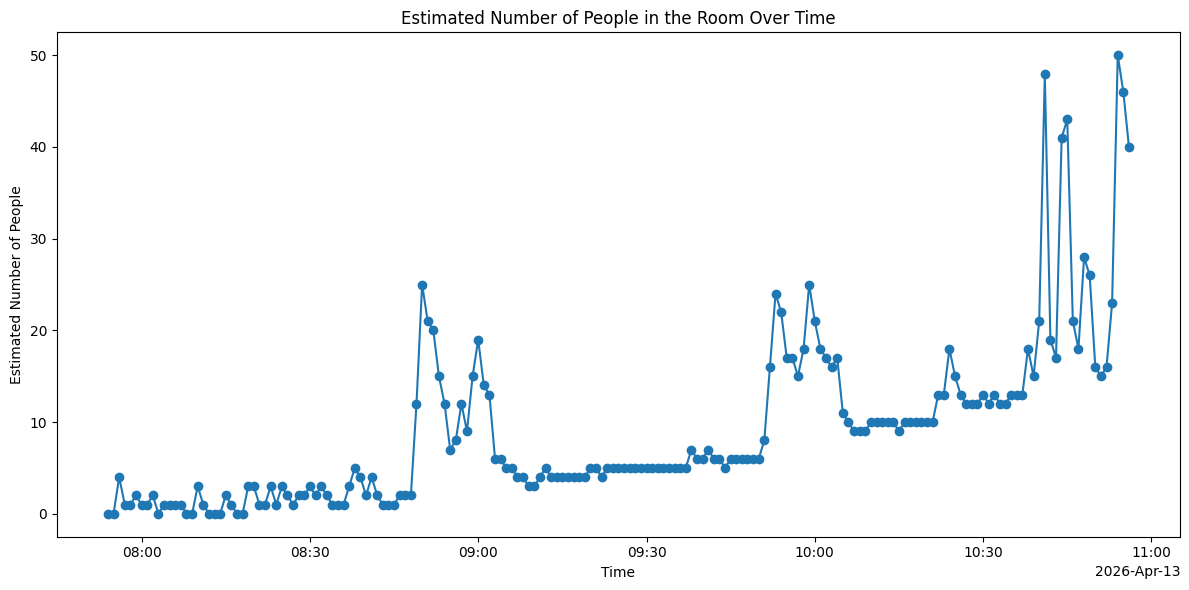

In [6]:
df['time'] = pd.to_datetime(df['time'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['time'], est_people, marker='o', linestyle='-')

locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.title('Estimated Number of People in the Room Over Time')
plt.xlabel('Time')
plt.ylabel('Estimated Number of People')
plt.tight_layout()
plt.show()

Room volume : 516,470 L  |  C_out : 423.0 ppm  |  G : 0.005 L/s/person
CO2 range   : 424 – 862 ppm
Airflow     : 515 – 777 L/s

Time                    Steady  Dynamic  Hybrid     CO2         Vib
----------------------------------------------------------------------
2026-04-13 07:54:00        1.7      2.4       2   424.0    0.001061
2026-04-13 07:55:00        1.8      1.8       2   432.0    0.001080
2026-04-13 07:56:00        1.7      5.0       2   462.0    0.001058
2026-04-13 07:57:00        2.2      7.1       2   441.0    0.001046
2026-04-13 07:58:00        2.3      0.0       2   438.0    0.000990
2026-04-13 07:59:00        1.8      0.0       2   445.0    0.000963
2026-04-13 08:00:00        1.9      1.0       2   439.5    0.000918
2026-04-13 08:01:00        1.7      0.0       2   439.5    0.000923
2026-04-13 08:02:00        1.5      0.0       2   444.5    0.000907
2026-04-13 08:03:00        1.4      0.3       1   429.5    0.000890
2026-04-13 08:04:00        1.4      0.5       1   434

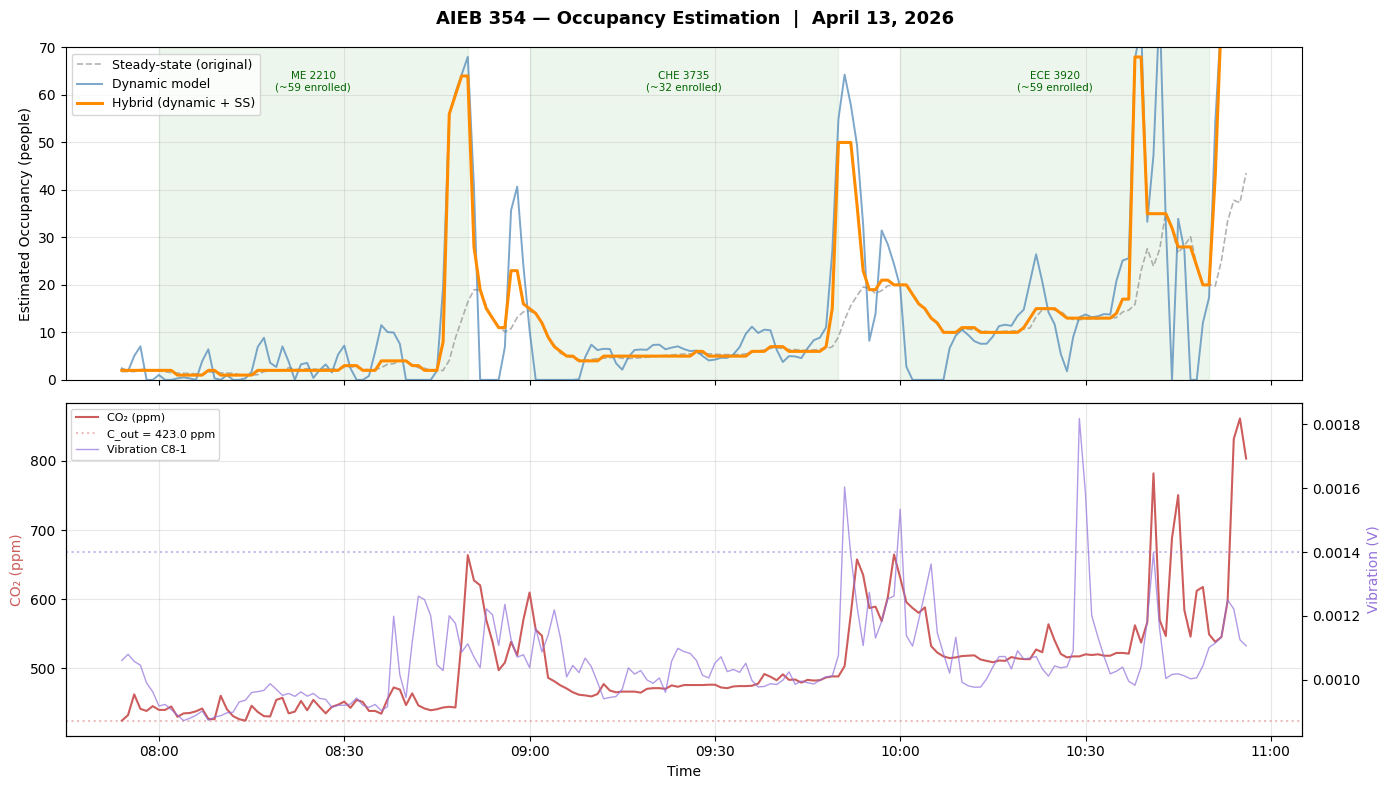

In [7]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('data/4-13-2026_rm354_FPB(clean)(vibration).csv')
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# ── Constants ──────────────────────────────────────────────────────────────────
ROOM_AREA_FT2 = 1403                                       # AIEB 354 floor area
CEILING_FT    = 13
ROOM_M3       = (ROOM_AREA_FT2 * CEILING_FT) * 0.0283168   # ft³ → m³
ROOM_LITERS   = ROOM_M3 * 1000                             # ~516,400 L

C_OUT         = 423.0    # ppm — outdoor/background CO2
G             = 0.005    # L/s/person — CO2 generation rate (ASHRAE standard)
DT            = 60.0     # seconds per timestep

VIB_COL       = ' C8-1(v)'
VIB_THRESHOLD = 0.0014   # vibration spike = people transitioning

# ── Preprocessing ──────────────────────────────────────────────────────────────
# Smooth CO2 before taking derivative — prevents single-sample spikes from
# exploding the accumulation term in the dynamic model
df['Q_ls']       = df['air_flow'] * 0.47194745           # CFM → L/s
df['co2_smooth'] = df['co2'].rolling(window=5, center=True, min_periods=1).mean()

# ── Model 1: Steady-state (original) ──────────────────────────────────────────
df['N_steady'] = np.maximum(0,
    df['Q_ls'] * ((df['co2_smooth'] - C_OUT) / 1_000_000) / G
)

# ── Model 2: Dynamic (transient CO2 mass balance) ─────────────────────────────
#
#   Full mass balance for a well-mixed room:
#
#       V * dC/dt  =  G*N  -  Q*(C - C_out)
#
#   Solving for N:
#
#       N = [ V*(dC/dt) + Q*(C - C_out) ] / G
#
#   Derivative is clamped to MAX_DCDT to prevent noise amplification.
#   Max plausible dC/dt: 60 people, zero ventilation →
#       (60 * 0.005 * 1e6) / 516400 ≈ 0.58 ppm/s

MAX_DCDT = 0.5   # ppm/s

co2_arr  = df['co2_smooth'].values
dCdt_arr = np.gradient(co2_arr, DT)   # ppm/s via central differences

N_dynamic = []
for i in range(len(df)):
    Q    = df['Q_ls'].iloc[i]
    C    = co2_arr[i]
    dCdt = np.clip(dCdt_arr[i], -MAX_DCDT, MAX_DCDT)

    accumulation = ROOM_LITERS * (dCdt        / 1_000_000)
    ventilation  = Q           * ((C - C_OUT) / 1_000_000)

    N_dynamic.append(max(0.0, (accumulation + ventilation) / G))

df['N_dynamic'] = N_dynamic

# ── Model 3: Hybrid ────────────────────────────────────────────────────────────
#
#   Rules:
#   - CO2 rising or vibration spike → blend dynamic + steady-state
#     (dynamic weighted higher when CO2 is rising faster)
#   - CO2 stable or falling → steady-state only
#     (equilibrium approximation holds; derivative adds noise)
#   Final pass: rolling median to smooth the combined estimate.

N_hybrid = []
for i in range(len(df)):
    dCdt   = dCdt_arr[i]
    is_vib = df[VIB_COL].iloc[i] > VIB_THRESHOLD
    N_ss   = df['N_steady'].iloc[i]
    N_dyn  = df['N_dynamic'].iloc[i]

    if is_vib or dCdt > 0.05:
        weight = min(1.0, abs(dCdt) / MAX_DCDT)
        N = weight * N_dyn + (1 - weight) * N_ss
    else:
        N = N_ss

    N_hybrid.append(max(0.0, N))

df['N_hybrid'] = (pd.Series(N_hybrid)
                  .rolling(window=3, center=True, min_periods=1)
                  .median()
                  .clip(lower=0)
                  .round()
                  .astype(int))

# ── Print results ──────────────────────────────────────────────────────────────
print("=" * 70)
print(f"Room volume : {ROOM_LITERS:,.0f} L  |  C_out : {C_OUT} ppm  |  G : {G} L/s/person")
print(f"CO2 range   : {df['co2'].min():.0f} – {df['co2'].max():.0f} ppm")
print(f"Airflow     : {df['Q_ls'].min():.0f} – {df['Q_ls'].max():.0f} L/s")
print("=" * 70)
print(f"\n{'Time':<22} {'Steady':>7} {'Dynamic':>8} {'Hybrid':>7}  {'CO2':>6}  {'Vib':>10}")
print("-" * 70)
for _, row in df.iterrows():
    flag = "  ◀ vib" if row[VIB_COL] > VIB_THRESHOLD else ""
    print(f"{str(row['time']):<22} {row['N_steady']:>7.1f} {row['N_dynamic']:>8.1f} "
          f"{row['N_hybrid']:>7}  {row['co2']:>6.1f}  {row[VIB_COL]:>10.6f}{flag}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("AIEB 354 — Occupancy Estimation  |  April 13, 2026", fontsize=13, fontweight='bold')

ax1.plot(df['time'], df['N_steady'],  label='Steady-state (original)', lw=1.2, ls='--', color='gray',      alpha=0.6)
ax1.plot(df['time'], df['N_dynamic'], label='Dynamic model',           lw=1.4,          color='steelblue', alpha=0.7)
ax1.plot(df['time'], df['N_hybrid'],  label='Hybrid (dynamic + SS)',   lw=2.2,          color='darkorange')

classes = [
    ("ME 2210\n(~59 enrolled)",  "08:00", "08:50"),
    ("CHE 3735\n(~32 enrolled)", "09:00", "09:50"),
    ("ECE 3920\n(~59 enrolled)", "10:00", "10:50"),
]
for label, s, e in classes:
    s_ts = pd.Timestamp(f"2026-04-13 {s}")
    e_ts = pd.Timestamp(f"2026-04-13 {e}")
    ax1.axvspan(s_ts, e_ts, alpha=0.07, color='green')
    ax1.text(s_ts + (e_ts - s_ts) / 2, 65, label,
             ha='center', va='top', fontsize=7.5, color='darkgreen')

ax1.set_ylabel("Estimated Occupancy (people)")
ax1.set_ylim(0, 70)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

ax2b = ax2.twinx()
ax2.plot( df['time'], df['co2'],     color='indianred',    lw=1.5, label='CO₂ (ppm)')
ax2b.plot(df['time'], df[VIB_COL],  color='mediumpurple', lw=1.0, alpha=0.7, label='Vibration C8-1')
ax2b.axhline(VIB_THRESHOLD, color='mediumpurple', ls=':', alpha=0.5)
ax2.axhline(C_OUT, color='indianred', ls=':', alpha=0.4, label=f'C_out = {C_OUT} ppm')

ax2.set_ylabel("CO₂ (ppm)",      color='indianred')
ax2b.set_ylabel("Vibration (V)", color='mediumpurple')
ax2.set_xlabel("Time")
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

lines  = ax2.get_legend_handles_labels()[0]  + ax2b.get_legend_handles_labels()[0]
labels = ax2.get_legend_handles_labels()[1] + ax2b.get_legend_handles_labels()[1]
ax2.legend(lines, labels, loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/occupancy_estimate.png', dpi=150, bbox_inches='tight')
print("\nPlot saved to occupancy_estimate.png")